### Team Members:
- Aidan Ogasawara
- Edison Chen
- Felix Watt

# Phase II: Data Curation, Exploratory Analysis and Plotting (5\%)

### Due (Each Group): October 26

Each **project group** will submit a single **jupyter notebook** which contains:

1. (1\%) Expresses the central motivation of the project and explains the (at least) two key questions to be explored. Gives a summary of the data processing pipeline so a technical expert can easily follow along.


### General Project Understanding: 
Our general project focuses on a food API as we are taking the nutrients within the data to produce a recipe with the desired nutrients requested by the user. 

### Phase 2: 

### Central Motivation of Project: 
Our central motivation of the project focuses on gathering nutritional data such as food categories to predict food macros or gathering food macros to predict food categories. This could possibly be scaled up to recipes in the future but our focus is using this project to provide users with better dietary and nutritional data and understanding.  

---

### Questions to be Explored:  

- How influential are specific food items within certain categories (proteins, fibers, lipids) towards a user’s diet? 

- What noticeable patterns within the data cause different food options to create such stark nutritional benefits? 

---

### Summary of Data Processing Pipeline


Data: USDA API - "https://api.nal.usda.gov/fdc/v1/foods/search" 

We are gathering data from this USDA API that takes data including specific food, its category and preparation method, and then the data that come with the specific food such as proteins, fats, carbs, sugars, fiber, calories.  

 

Data Cleaning 

We cleared NaN values by setting them to 0, removed the columns that included starch, fructose, lactose, along with molecules such as leucine, lysine, cystine, and arginine. We decided to focus on more user-friendly categories such as the protein, fats, and fibers.  Categories also got transformed into a category list in python. By turning the categories into a list, it made the categories easier to process rather than the string representing the multiple categories for a specific meal.  

 

Data Visualization 

To visualize the data, we were looking towards the direction of finding connections and correlations between different categories of the dataset. For example, we would look at how carbohydrates correlated to sodium or how they relate to proteins. Graphs can also create multiple lines of different types of foods such as meats, vegetables, and carbs, all have different results and connections between nutrients.  This could be created through bar graphs or line graphs.  

2. (2\%) Obtains, cleans, and merges all data sources involved in the project.

In [321]:
import requests
import pandas as pd
import seaborn as sns

API_KEY = "k2M74ySGzcLGRv5hqCWz3Hr5a63Y1V3NLGRxY2Sf"
BASE_URL = "https://api.nal.usda.gov/fdc/v1/foods/search"

def get_macros(food):
    """
    Get nutrition information for a given food using the USDA API. 
    """
    params = {
        "query": food,
        "pageSize": 50,
        "api_key": API_KEY
    }

    response = requests.get(BASE_URL, params=params)
    if response.status_code != 200:
        raise Exception(f"Error: {response.status_code} - {response.text}")

    data = response.json()
    foods = []

    for item in data.get("foods", []):
        description = item.get("description")
        category = item.get("foodCategory")
        
        nutrients = {}
        for n in item.get("foodNutrients", []):
            name = n.get("nutrientName")
            value = n.get("value")
            if name and value is not None:
                nutrients[name] = value
        
        food_entry = {
            "Food": food,
            "Description": description,
            "Category": category,
            "category_list": [c.strip() for c in category.split(',')] if category else []
        }
        food_entry.update(nutrients)
        foods.append(food_entry)

    return pd.DataFrame(foods)

# An example recipe
food_list = [salmon", "broccoli", "rice"]

all_foods_df = pd.concat([get_macros(food) for food in food_list], ignore_index=True)
all_foods_df['category_list'] = all_foods_df['Category'].str.split(',').apply(lambda x: [c.strip() for c in x])

pd.set_option("display.max_columns", None)
all_foods_df.head()

,Food,Description,Category,category_list,Protein,Total lipid (fat),"Carbohydrate, by difference",Energy,Total Sugars,"Fiber, total dietary","Calcium, Ca","Iron, Fe","Sodium, Na","Vitamin A, IU","Vitamin C, total ascorbic acid",Cholesterol,"Fatty acids, total trans","Fatty acids, total saturated","Fatty acids, total monounsaturated","Fatty acids, total polyunsaturated","Potassium, K",Vitamin D (D2 + D3),"Sugars, added","Alcohol, ethyl",Water,Caffeine,Theobromine,"Magnesium, Mg","Phosphorus, P","Zinc, Zn","Copper, Cu","Selenium, Se",Retinol,"Vitamin A, RAE","Carotene, beta","Carotene, alpha",Vitamin E (alpha-tocopherol),"Cryptoxanthin, beta",Lycopene,Lutein + zeaxanthin,Thiamin,Riboflavin,Niacin,Vitamin B-6,"Folate, total",Vitamin B-12,"Choline, total",Vitamin K (phylloquinone),Folic acid,"Folate, food","Folate, DFE","Vitamin E, added","Vitamin B-12, added",SFA 4:0,SFA 6:0,SFA 8:0,SFA 10:0,SFA 12:0,SFA 14:0,SFA 16:0,SFA 18:0,MUFA 18:1,PUFA 18:2,PUFA 18:3,PUFA 20:4,PUFA 22:6 n-3 (DHA),MUFA 16:1,PUFA 18:4,MUFA 20:1,PUFA 20:5 n-3 (EPA),MUFA 22:1,PUFA 22:5 n-3 (DPA),Galactose,"Manganese, Mn",Ash,Starch,Fructose,Lactose,Hydroxyproline,Vitamin K (Dihydrophylloquinone),SFA 22:0,MUFA 14:1,SFA 17:0,SFA 24:0,Sucrose,Glucose,Maltose,Pantothenic acid,SFA 20:0,Betaine,SFA 15:0,Isoleucine,Leucine,Lysine,Cystine,Valine,Arginine,Histidine,Aspartic acid,Serine,Tryptophan,Threonine,Methionine,Phenylalanine,Tyrosine,Alanine,Glutamic acid,Glycine,Proline,"Vitamin D (D2 + D3), International Units","Tocopherol, gamma",Phytosterols,Nitrogen,Energy (Atwater General Factors),Energy (Atwater Specific Factors),"PUFA 18:3 n-6 c,c,c","Tocopherol, beta","Tocotrienol, alpha","Tocotrienol, beta",TFA 22:1 t,PUFA 20:3 n-3,PUFA 22:4,MUFA 22:1 c,MUFA 15:1,MUFA 24:1 c,"Tocopherol, delta","Tocotrienol, delta",TFA 18:2 t not further defined,PUFA 18:2 CLAs,"PUFA 20:2 n-6 c,c",MUFA 16:1 c,TFA 18:1 t,PUFA 20:3,"Fatty acids, total trans-polyenoic",PUFA 20:3 n-6,"Tocotrienol, gamma",TFA 16:1 t,MUFA 18:1 c,"PUFA 18:3 n-3 c,c,c (ALA)",MUFA 17:1,"Fatty acids, total trans-monoenoic","PUFA 18:2 n-6 c,c",Vitamin D3 (cholecalciferol),Vitamin K (Menaquinone-4),PUFA 18:3i,"Iodine, I",PUFA 21:5,Vitamin D2 (ergocalciferol),PUFA 20:4 n-6,"Fiber, insoluble","Fiber, soluble",Phytoene,Phytofluene,"Sugars, Total","Carbohydrate, by summation",MUFA 14:1 c,MUFA 17:1 c,MUFA 20:1 c,PUFA 18:2 c,PUFA 18:3 c,PUFA 20:3 c,PUFA 20:4c,PUFA 20:2 c,Total fat (NLEA),"Fluoride, F",Campesterol,Stigmasterol,Beta-sitosterol,SFA 13:0
0,chicken breast,CHICKEN BREAST,"Poultry, Chicken & Turkey","[Poultry, Chicken & Turkey]",20.4,8.10,1.06,165.0,0.70,0.0,158.0,0.38,433.0,352.0,1.7,67.0,0.0,4.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chicken breast,CHICKEN BREAST,"Pepperoni, Salami & Cold Cuts","[Pepperoni, Salami & Cold Cuts]",14.3,8.93,3.57,143.0,0.00,0.0,0.0,1.29,929.0,0.0,0.0,54.0,0.0,1.79,3.57,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [322]:
def clean_macros(df):
    """
    Cleans and standardizes the USDA food dataset.
    - Keeps key macronutrients
    - Handles missing/negative values
    - Renames columns for clarity
    """
    df.columns = (
        df.columns.str.strip()
                  .str.lower()
                  .str.replace(" ", "_")
                  .str.replace("(", "", regex=False)
                  .str.replace(")", "", regex=False)
    )

    key_cols = [
        "food", "description", "category", "category_list", 
        "protein", "total_lipid_fat", "carbohydrate,_by_difference", "energy",
        "total_sugars", "sodium,_na", "iron,_fe", "fiber,_total_dietary", 
        "cholesterol", "fatty_acids,_total_saturated", "sugars,_added"
    ]
    df = df[[col for col in df.columns if col in key_cols]].copy()

    df.rename(columns={
        "energy": "calories",
        "total_lipid_fat": "fat_g",
        "carbohydrate,_by_difference": "carbs_g",
        "protein": "protein_g",
        "total_sugars": "sugar_g",
        "fiber,_total_dietary": "fiber_g",
        "sodium,_na" : "sodium",
        "iron,_fe" : "iron",
        "fatty_acids,_total_saturated" : "saturated_fats",
        "sugars,_added" : "added_sugars"
    }, inplace=True)

    numeric_cols = ["calories", "protein_g", "fat_g", "carbs_g", "sugar_g", "fiber_g", "cholesterol", "sodium", "iron", "saturated_fats", "added_sugars"]
    numeric_cols_in_df = [col for col in numeric_cols if col in df.columns]  # APi returns a different set of nutrients based on what the requested food has
    for col in numeric_cols_in_df:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df[numeric_cols_in_df] = df[numeric_cols_in_df].fillna(0)

    df[numeric_cols_in_df] = df[numeric_cols_in_df].clip(lower=0)

    df.drop_duplicates(subset=["description", "category"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df
all_foods_df_cleaned = clean_macros(all_foods_df)
all_foods_df_cleaned.iloc[:,:16].head(5)

,food,description,category,category_list,protein_g,fat_g,carbs_g,calories,sugar_g,fiber_g,iron,sodium,cholesterol,saturated_fats,added_sugars
0,chicken breast,CHICKEN BREAST,"Poultry, Chicken & Turkey","[Poultry, Chicken & Turkey]",20.4,8.10,1.06,165.0,0.70,0.0,0.38,433.0,67.0,4.58,0.0
1,chicken breast,CHICKEN BREAST,"Pepperoni, Salami & Cold Cuts","[Pepperoni, Salami & Cold Cuts]",14.3,8.93,3.57,143.0,0.00,0.0,1.29,929.0,54.0,1.79,0.0
2,chicken breast,CHICKEN BREAST,Cooked & Prepared,[Cooked & Prepared],19.6,1.79,1.79,107.0,1.79,0.0,0.64,857.0,71.0,0.00,0.0
3,chicken breast,CHICKEN BREAST,Canned Meat,[Canned Meat],21.4,1.79,0.00,107.0,0.00,0.0,0.64,411.0,45.0,0.00,0.0
4,chicken breast,CHICKEN BREAST,Other Deli,[Other Deli],11.4,4.16,5.71,96.0,0.52,1.3,0.47,210.0,32.0,0.65,0.0


3. (2\%) Builds at least two visualizations (graphs/plots) from the data which help to understand or answer the questions of interest. These visualizations will be graded based on how much information they can effectively communicate to readers. Please make sure your visualization are sufficiently distinct from each other.

<Axes: xlabel='cholesterol', ylabel='food'>

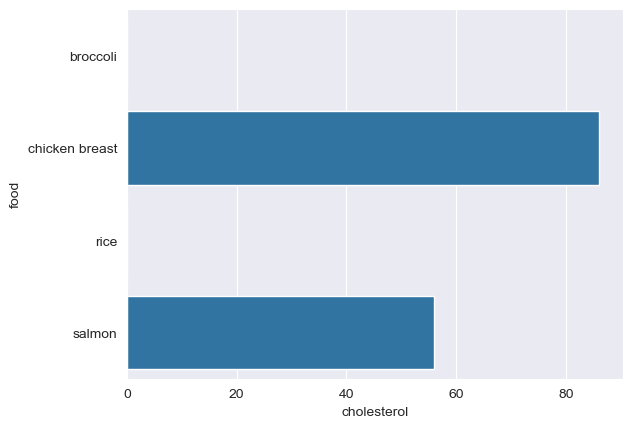

In [324]:
cholesterol_df = all_foods_df_cleaned.groupby('food')['cholesterol'].median()
sns.barplot(pd.DataFrame(cholesterol_df), x="cholesterol", y="food", orient="y")

From this plot we gain great insight into how the foods in our meal influence our daily cholesterol (question 1). From this graph, it's clear to see that salmon and chicken breast and salmon significantly contribute to our daily cholesterol, whilst rice and brocolli don't influence cholesterol at all. Importantly, what this graph communicates to someone hwo may be trying to limit their daily cholesterol is that they should look to substitute the chicken and salmon in their meal.

In [325]:
import plotly.express as px
fig = px.scatter(data_frame=all_foods_df_cleaned, x="protein_g", y="cholesterol", color="food", hover_data=["category"])
fig

This plot, expands on the last now analyzing the relationship between protein and cholesterol found in our meal. Importantly, what this graph suggests is that there is a direct relationship between protein and cholesterol. Considering many people try to minimize cholesterol and maximize protein this graph makes an interesting point that some foods may be both good and bad for your diet as they contain various macronutrients both good and bad. Crucially, this illustrates the complexity of eating to eat healthy, and the necessity for a project and ml like the one we intend to build that can find optimal solutions for diet goals.

<Axes: xlabel='calories', ylabel='food'>

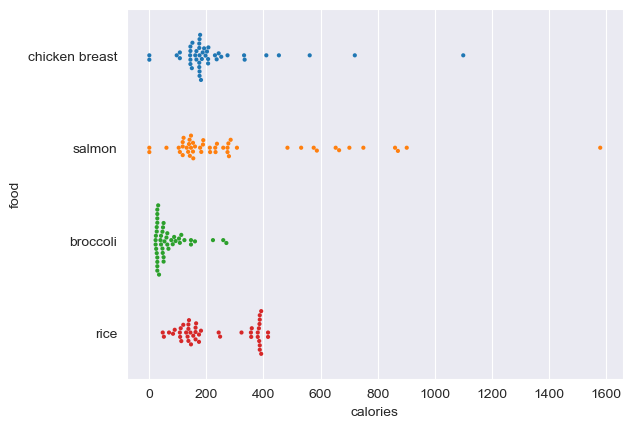

In [326]:
sns.swarmplot(data=all_foods_df_cleaned, x="calories", y="food", hue="food", size=3)

Lastly, this plot demonstrates how our different foods in our meal affect our calories. Its implications are similar to the first plot, but importantly, this plot also shows the distribution. This show us that, for example, broccoli almost always has very few calories, whereas salmon has a large range of options, some calorie rich and other less. To the consumer this may help them identify for which foods they can easily switch out product to adjust their calorie intake and which ones are much more fixed.

In [327]:
#A cool graph but not part of the submission
# import seaborn as sns
# expanded_df = all_foods_df_cleaned.explode('category_list') # turns category list into individual categories
# top_categories = list(expanded_df["category_list"].value_counts().iloc[:11].index)
# expanded_df = expanded_df[expanded_df['category_list'].isin(top_categories)]
# expanded_df = expanded_df.groupby('category_list')
# cholesterol_df = expanded_df["cholesterol"].median()
# sns.barplot(pd.DataFrame(cholesterol_df).iloc[1:16], x="cholesterol", y="category_list", orient="y")

A graph of the top 10 food categories in our meal by count and their median cholesterol. Kinda cool graph but I think the categories are too in concise/inconsistent to keep.

# Phase III: First ML Proof of Concept (5\%)

### When: November 23

Each **project group** will submit a single **jupyter notebook** which contains:

1. (2%) The implementation (using NumPy) of your first ML model as a function call to the cleaned data
2. (3%) A discussion of the preliminary results:
   - This may include checking of assumptions, generated plots/tables, measures of fit, or other attributes of the analysis
   - It does not have to be fully correct, but as a proof of concept must demonstrate that the group is close to completing the analysis
   - You **must** discuss some of the potential ethical considerations (or explain why there aren't any) for your project

In [328]:
def add_bias_column(X):
    """
    Args:
        X (array): can be either 1-d or 2-d
    
    Returns:
        Xnew (array): the same array, but 2-d with a column of 1's in the first spot
    """
    
    # If the array is 1-d
    if len(X.shape) == 1:
        Xnew = np.column_stack([np.ones(X.shape[0]), X])
    
    # If the array is 2-d
    elif len(X.shape) == 2:
        bias_col = np.ones((X.shape[0], 1))
        Xnew = np.hstack([bias_col, X])
        
    else:
        raise ValueError("Input array must be either 1-d or 2-d")

    return Xnew

In [329]:
def line_of_best_fit(X, y):
    """
    Calculates the coefficients for the line of best fit using least squares.

    Args:
        X (array): A 1D or 2D numpy array.
        y (array): A 1D numpy array of values mapping to values in rows of X.
    Returns:
        w (array): A 1D numpy array of coefficients. The first element is the intercept.
    """
    X_bias = add_bias_column(X)

    w = np.linalg.inv(X_bias.T @ X_bias) @ (X_bias.T @ y)

    return w

In [330]:
def linreg_predict(Xnew, ynew, m):
    """
    Generates predictions for a linear regression model.

    Args:
        Xnew (array): 1D or 2D numpy array.
        ynew (array): 1D numpy array of actual values.
        m (array): 1D numpy array of length p+1 containing line of best fit coefficients.

    Returns:
        dict: A dictionary with keys:
            - 'ypreds': predicted values
            - 'resids': residuals 
            - 'mse': mean squared error
            - 'r2': coefficient of determination
    """
    X_bias = add_bias_column(Xnew)

    ypreds = X_bias @ m
    resids = ynew - ypreds
    mse = np.mean(resids**2)
    r2 = r2_score(ynew, ypreds)

    return {
        'ypreds': ypreds,
        'resids': resids,
        'mse': mse,
        'r2': r2
    }

In [331]:
def remove_outliers_iqr(df, columns):
    """
        Remove outliers using the Interquartile Range method
    """
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

### Model 1 Linear Regression

In [332]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import r2_score

cols_to_clean = ['protein_g', 'fat_g', 'carbs_g', 'calories']
df_no_outliers = remove_outliers_iqr(all_foods_df_cleaned, cols_to_clean)

X = df_no_outliers[['protein_g', 'fat_g', 'carbs_g']].values
y = df_no_outliers['calories'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

coefficients = line_of_best_fit(X_train, y_train)
results = linreg_predict(X_test, y_test, coefficients)
print("MODEL PERFORMANCE")
print(f"MSE: {results['mse']}")
print(f"R^2: {results['r2']}")

MODEL PERFORMANCE
MSE: 2996.5419586782987
R^2: 0.4369934053587271


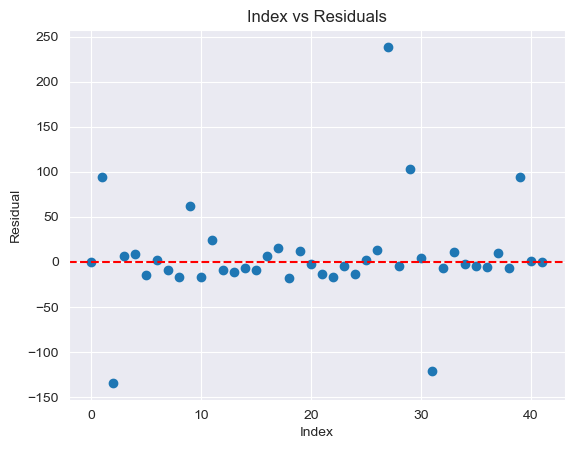

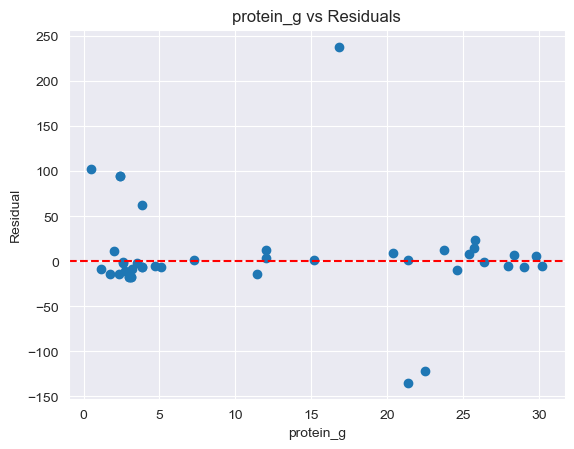

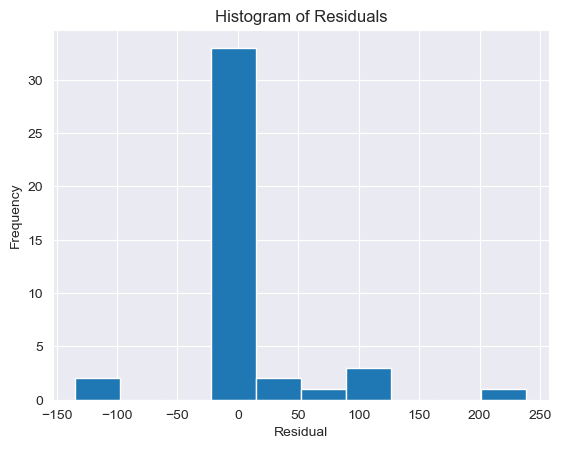

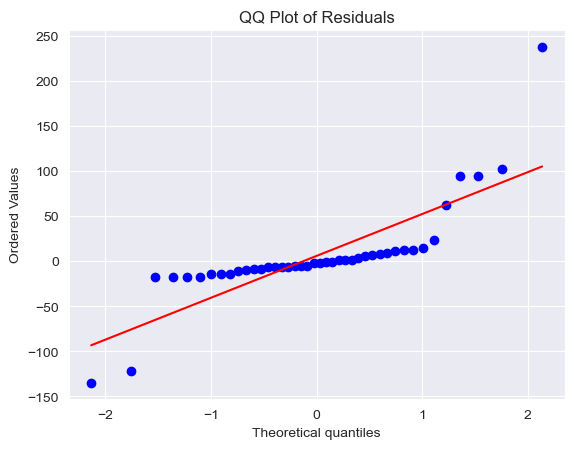

In [333]:
import matplotlib.pyplot as plt
from scipy import stats

y_pred = results['ypreds']
residuals = y_test - y_pred

#residual plot
plt.scatter(range(len(residuals)), residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Index")
plt.ylabel("Residual")
plt.title("Index vs Residuals")
plt.show()

#protein vs residuals
plt.scatter(X_test[:, 0], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("protein_g")
plt.ylabel("Residual")
plt.title("protein_g vs Residuals")
plt.show()

#histogram
plt.hist(residuals)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

#QQ plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()

### Independence: 
The "Index vs. Residuals" showed mainly scattered points mainly around the zero without any clear patterns or trends. In addition to that, there is no clear clusters or correlations which are apparent in the graph. Therefore this most likely points that this satisfies the independence test. 
### Constant Variance/Linearity: 
The "protein_g vs. Residuals" plot shows mainly that the residuals are randomly scarred around zero, and that the spread appears to be consistent across the entire range of protein_g. There isn't any "fanning" patterns which would have indicated heteroscedasticity. The random scatter throughout the zero supprts the linearity assumption for the data not including some of the major outliars.
### Normality: 
The histogram points that there is  a heavy concentration around the 0 and that there are also clear outliars on both tails. The QQ plot of residuals shows that there is a good fit in the middle range which include the points that follow the line but there are more outliars on the upper tail of the graph. Normality doesn't seem to hold as the points aren't clearly following the diagonal line seen in the QQ plot. 

### Conclusion
Overall, the plots show that the independence and constant variance are reasonable, but normality is violated due to may outliers. Combined with a below average R^2, this suggests that while the model does capture some relationship between protein and calories, it is not complete, and needs some additional predictors. 

## Model 2
Polynomial regression

In [334]:
df_no_outliers['fat_g_squared'] = df_no_outliers['fat_g']**2
df_no_outliers['fat_mult_Carbs'] = df_no_outliers['fat_g'] * df_no_outliers['carbs_g']
df_no_outliers['prot_squared'] = df_no_outliers['protein_g']**2
X_poly = df_no_outliers[['protein_g', 'fat_g', 'carbs_g', 'fat_g_squared', 'fat_mult_Carbs', 'prot_squared']].values
y = df_no_outliers['calories'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.3, random_state=42
)

coefficients = line_of_best_fit(X_train, y_train)
results = linreg_predict(X_test, y_test, coefficients)
print("MODEL PERFORMANCE")
print(f"MSE: {results['mse']}")
print(f"R^2: {results['r2']}")

MODEL PERFORMANCE
MSE: 2906.9344966561225
R^2: 0.45382934249668216


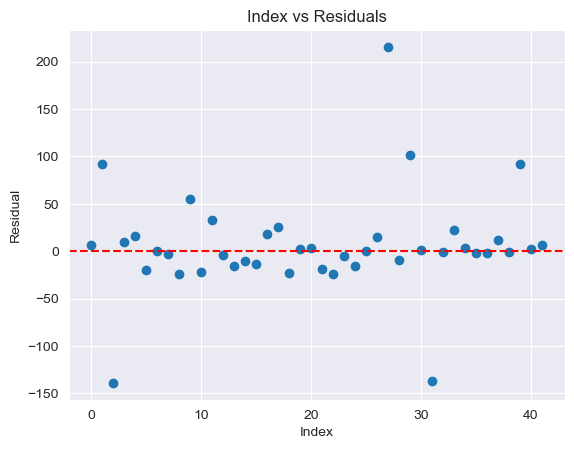

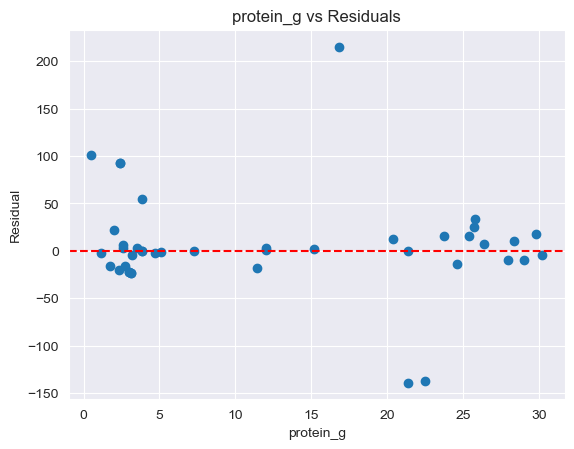

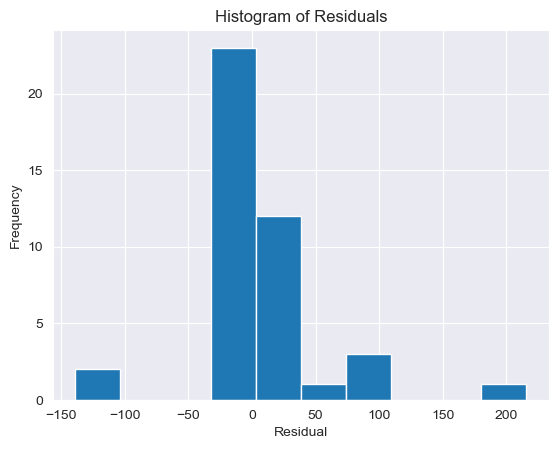

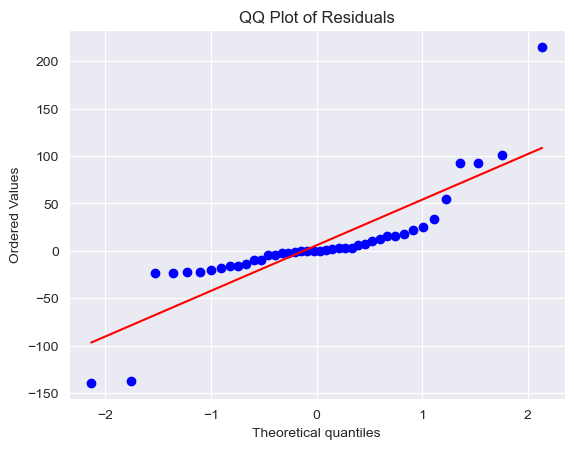

In [335]:
y_pred = results['ypreds']
residuals = y_test - y_pred

#residual plot
plt.scatter(range(len(residuals)), residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Index")
plt.ylabel("Residual")
plt.title("Index vs Residuals")
plt.show()

#protein vs residuals
plt.scatter(X_test[:, 0], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("protein_g")
plt.ylabel("Residual")
plt.title("protein_g vs Residuals")
plt.show()

#histogram
plt.hist(residuals)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

#QQ plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()

## Assumptions:
Looking at the residual graphs, they are almost identical to those of model 1.
## Conclusion:
This model, despite the change to being polynomial displays almost identical results to the first seeming to indicate that the polynomial terms have little to no effect. If anything, this corroborates that the relationship is linear and suggests that in order to make a better model we may need to change the predictors, and not regression models.

### Model 3

Pivoting away from calories, this model attempts to explore the relation between cholesterol and protein in a sample set of generic red meats.

Seperated cells to reduce the possibility of errors (The API fails like 50% of the time, I think it hates me personally)

In [336]:
beef = get_macros('beef')

In [337]:
meat = get_macros('meat')

In [343]:
pork = get_macros('pork')

In [345]:
lamb = get_macros('lamb')

In [346]:
meats_df = pd.concat([meat, beef, pork, lamb])
meats_df['category_list'] = meats_df['Category'].str.split(',').apply(lambda x: [c.strip() for c in x])

In [347]:
meats_df_clean = clean_macros(meats_df)
cols_to_clean = ['protein_g', 'cholesterol']
meats_df_clean = remove_outliers_iqr(meats_df_clean, cols_to_clean)
meats_df_clean.head()

,food,description,category,category_list,carbs_g,iron,protein_g,fat_g,calories,sugar_g,fiber_g,sodium,cholesterol,saturated_fats,added_sugars
0,meat,MEAT,Other Frozen Meats,[Other Frozen Meats],0.00,0.64,17.90,11.60,188.0,0.00,0.0,223.0,58.0,4.020,0.0
1,meat,MEAT,Other Meats,[Other Meats],0.00,0.64,17.90,11.60,188.0,0.00,0.0,223.0,58.0,4.020,0.0
2,meat,MEAT,"Bacon, Sausages & Ribs","[Bacon, Sausages & Ribs]",0.00,0.64,17.90,11.60,188.0,0.00,0.0,223.0,58.0,4.020,0.0
3,meat,"Meat loaf, NS as to type of meat",Meat mixed dishes,[Meat mixed dishes],7.20,2.05,17.49,11.04,202.0,1.81,0.4,416.0,78.0,4.138,0.0
4,meat,"Meat spread or potted meat, NFS",Cold cuts and cured meats,[Cold cuts and cured meats],11.94,0.79,7.66,17.34,235.0,0.00,0.2,1013.0,38.0,5.977,0.0


In [348]:
predictors = ['cholesterol']
target = 'protein_g'
X = meats_df_clean[predictors].values
y = meats_df_clean[target].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
coefficients = line_of_best_fit(X_train, y_train)
results = linreg_predict(X_test, y_test, coefficients)
print("MODEL PERFORMANCE")
print(f"MSE: {results['mse']}")
print(f"R^2: {results['r2']}")

MODEL PERFORMANCE
MSE: 23.69903591897538
R^2: 0.5211064618056902


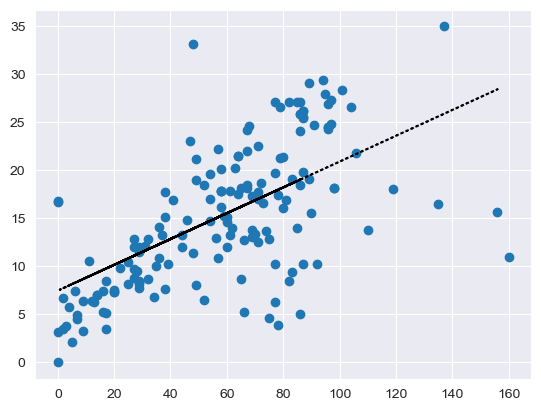

In [349]:
# this is for my own sake
plt.scatter(meats_df_clean['cholesterol'], meats_df_clean[target])
plt.plot(X_test, results['ypreds'], color='black',
                 ls=':',
                 label='linear fit')

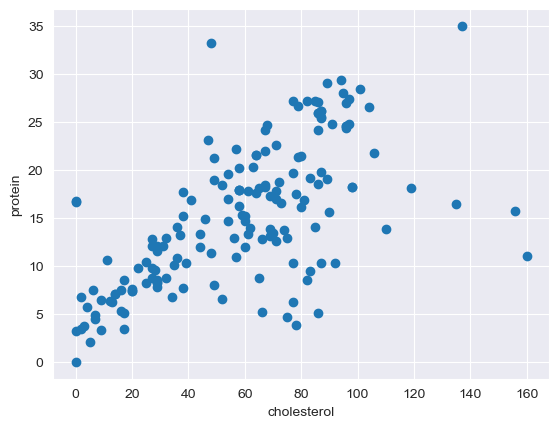

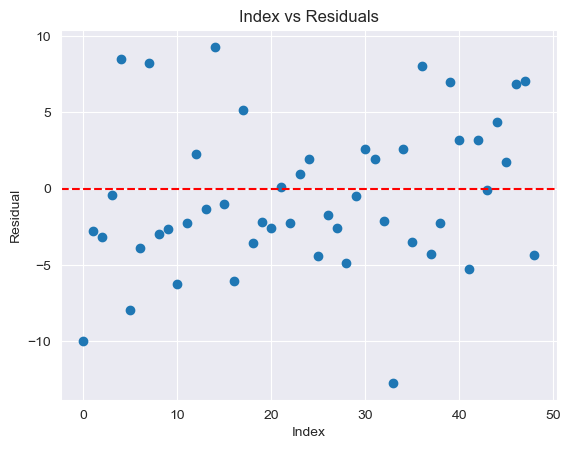

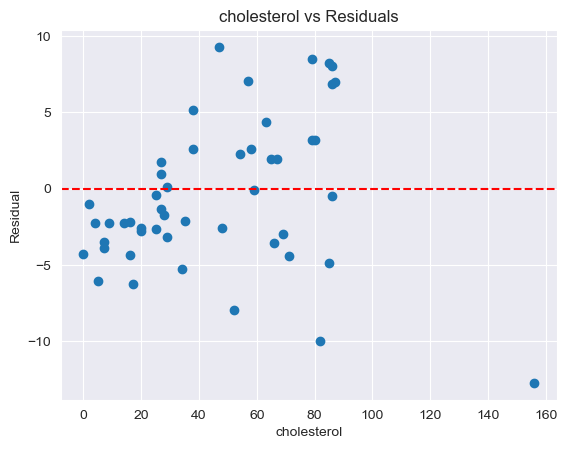

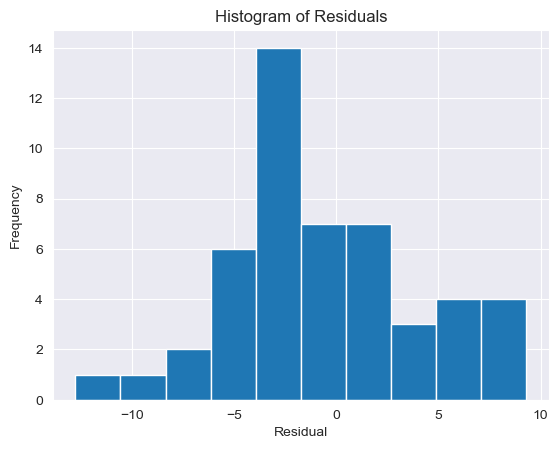

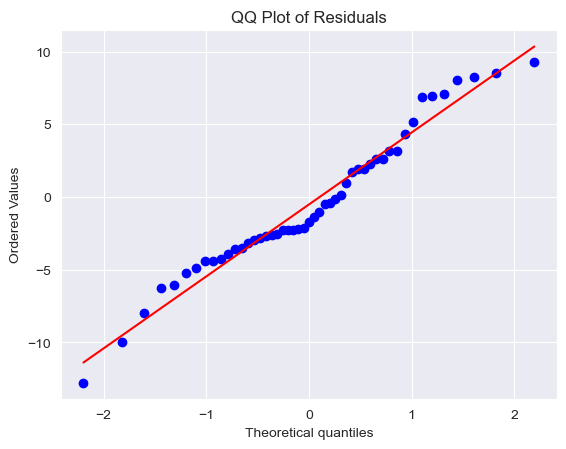

In [350]:
y_pred = results['ypreds']
residuals = y_test - y_pred

#x vs y
plt.scatter(X, y)
plt.xlabel("cholesterol")
plt.ylabel("protein")
plt.show()

#residual plot
plt.scatter(range(len(residuals)), residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Index")
plt.ylabel("Residual")
plt.title("Index vs Residuals")
plt.show()

#protein vs residuals
plt.scatter(X_test[:, 0], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("cholesterol")
plt.ylabel("Residual")
plt.title("cholesterol vs Residuals")
plt.show()

#histogram
plt.hist(residuals)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

#QQ plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()

## Independence
The residuals show a seemingly random scattering around 0 with some noticeable outliers. There doesn't seem to be much of any pattern.

## Constant Variance/Linearity:
 From the first plot and from the residuals plot we can gather that there seems to be mostly linearity however, some possible heteroscedasticity as the graph seems to fan out a bit. Overall, there is not much pattern to the residuals.
 
## Normality
The histogram and QQ plot show a normal distribution with a slight right skew, but overall, a relatively normal distribution.

## Conclusion

Based off the assumptions and the r^2, the model seems to be a good start but there seems to be unaccounted for factors that are producing outliers and increasing the variance of residuals as cholesterol increases. I think this model could maybe be improved by adding better predictors.


### Potential Ethical Considerations

Some of the most major ethical considerations include accuracy/health consequences, data bias, and data privacy. Firstly, the model won’t be able to 100% accurately predict the impacts of certain foods therefore if there were people who would follow this model, it may not be producing their desirable responses or answers. This could potentially cause problems as the model would be influencing users down a wrong path if they are looking for better health habits. Another issue behind the produced data is the data bias behind the dataset. The dataset is focused more on westernized food and won’t always be applicable to all users or all types of meals. Lastly, data privacy is the third ethical concern. As food intake reveals lifestyle patterns and looks into one’s personal life, the large amount of data going into the ML model can be particularly revealing and make individuals feel exposed.